# 384 Color screen

## Experiment

Two experiment were done with lake water in 384 well plates (and a follow-up). 

### 1 - Simple screen
Lake water was cultured in R2B to see what is the result, aiming for ~10 cell per well, but failed, concentration was much higher. 
For this experiment, we have the **plate reader data** and **scanner images**

### 2 - Cell concentration screen
To test the influence of cell concentration, 3 plates with 1, 5 & 25 cells per well according to estimations (probably more again).
Available data for this experiment : **plate reader data**, **scanner images** and medium quality **pictures**.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight

import joblib

## Data processing

Plate reader data were aggregated in 1 excel file and deblank was perform by applying norm_abs = (measure-blank)/blank, the blank being the mean absorbance of all control wells per wavelength. See excel file for details.
Annotations of color (tagging) was made manually based on scans and pictures.

# Data vizualisation

Before building a model, I want to check how is the data distribution.


In [2]:
# --- 1. LOAD & PREPARE DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # remove the "moyenne" row
ids = df_clean.iloc[:, 0:1]
abs_columns = df_clean.loc[:, '300':'800']
tags = df_clean.iloc[:, 27:29]
#print(df_clean.head)


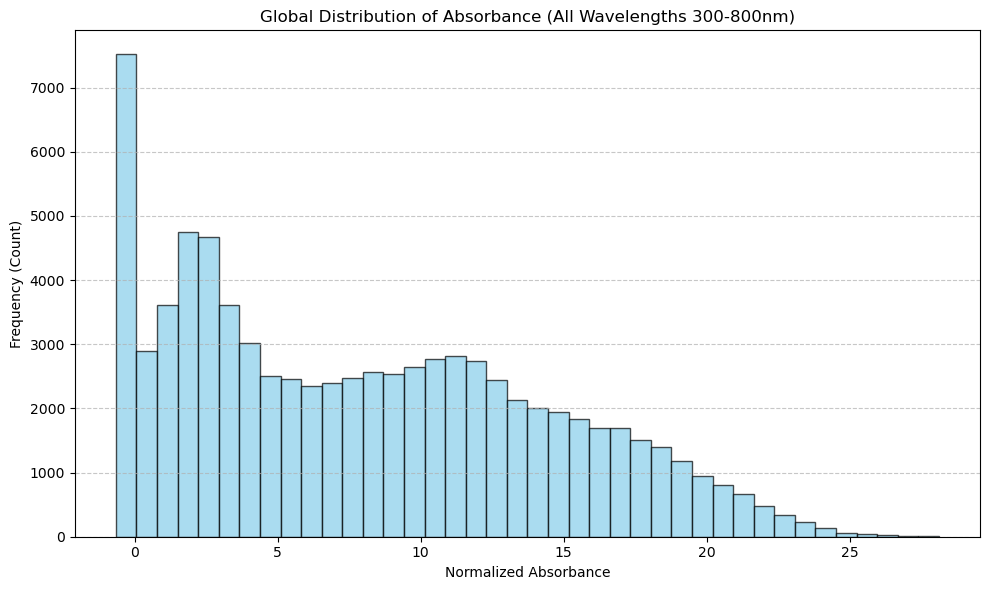

In [3]:
# Visualizing data
# 3. Data Cleaning for Plotting
# Flatten the dataframe to a single list of values for the global histogram
# dropna() removes empty wells, clip(lower=0) removes negative noise from blank subtraction
all_values = abs_columns.values.flatten()
#all_values = all_values[~np.isnan(all_values)] # Remove NaNs ==> already replaced > 4
#all_values = all_values[all_values >= 0]      # Remove negatives

# --- Plot 1: Global Histogram (All Wavelengths Combined) ---
plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Global Distribution of Absorbance (All Wavelengths 300-800nm)')
plt.xlabel('Normalized Absorbance')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




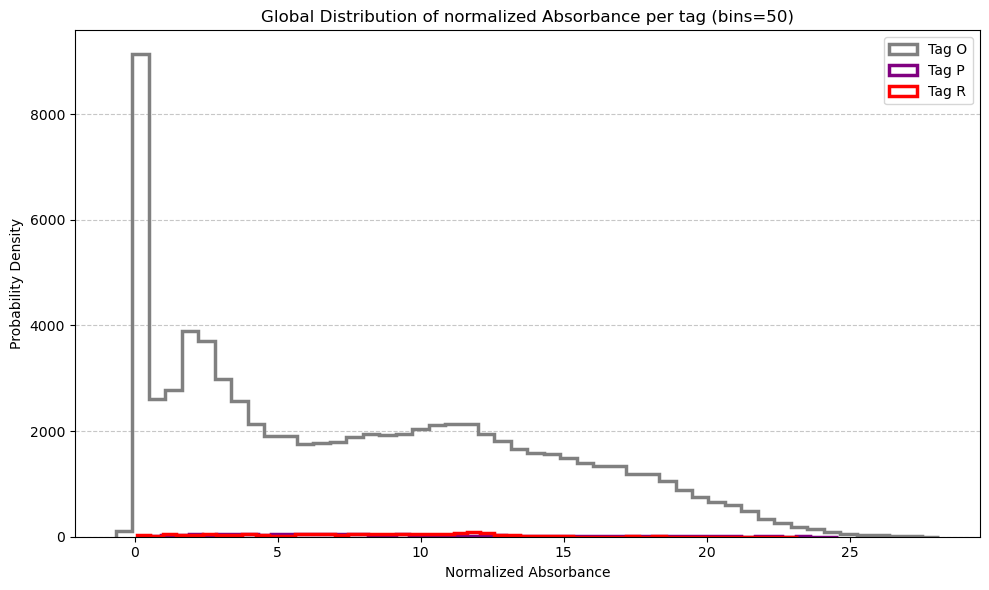

In [4]:
#---1bis - Global by tag


# 1. Prepare Data
cols = df_clean.loc[:, '300':'800'].columns
tags = ['O', 'P', 'R']
colors = {'O': 'gray', 'P': 'purple', 'R': 'red'}

plt.figure(figsize=(10, 6))

# 2. Loop through tags and plot curves
for tag in tags:
    # Filter data for this tag and flatten all wavelengths into one array
    subset = df[df['Color_label'] == tag][cols]
    values = subset.values.flatten()
    
    # Remove NaNs (negatives are kept as per your request)
    values = values[~np.isnan(values)]
    
    if len(values) > 0:
        # Plot histogram as a step curve (density)
        # density=True scales the area under the curve to 1, making tags comparable
        plt.hist(values, bins=50, density=False, histtype='step',         # /!\ Density=True > normalize 
                 linewidth=2.5, color=colors[tag], label=f'Tag {tag}')

# 3. Formatting
plt.title('Global Distribution of normalized Absorbance per tag (bins=50)')
plt.xlabel('Normalized Absorbance')
plt.ylabel('Probability Density') # Changed label because density=True
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

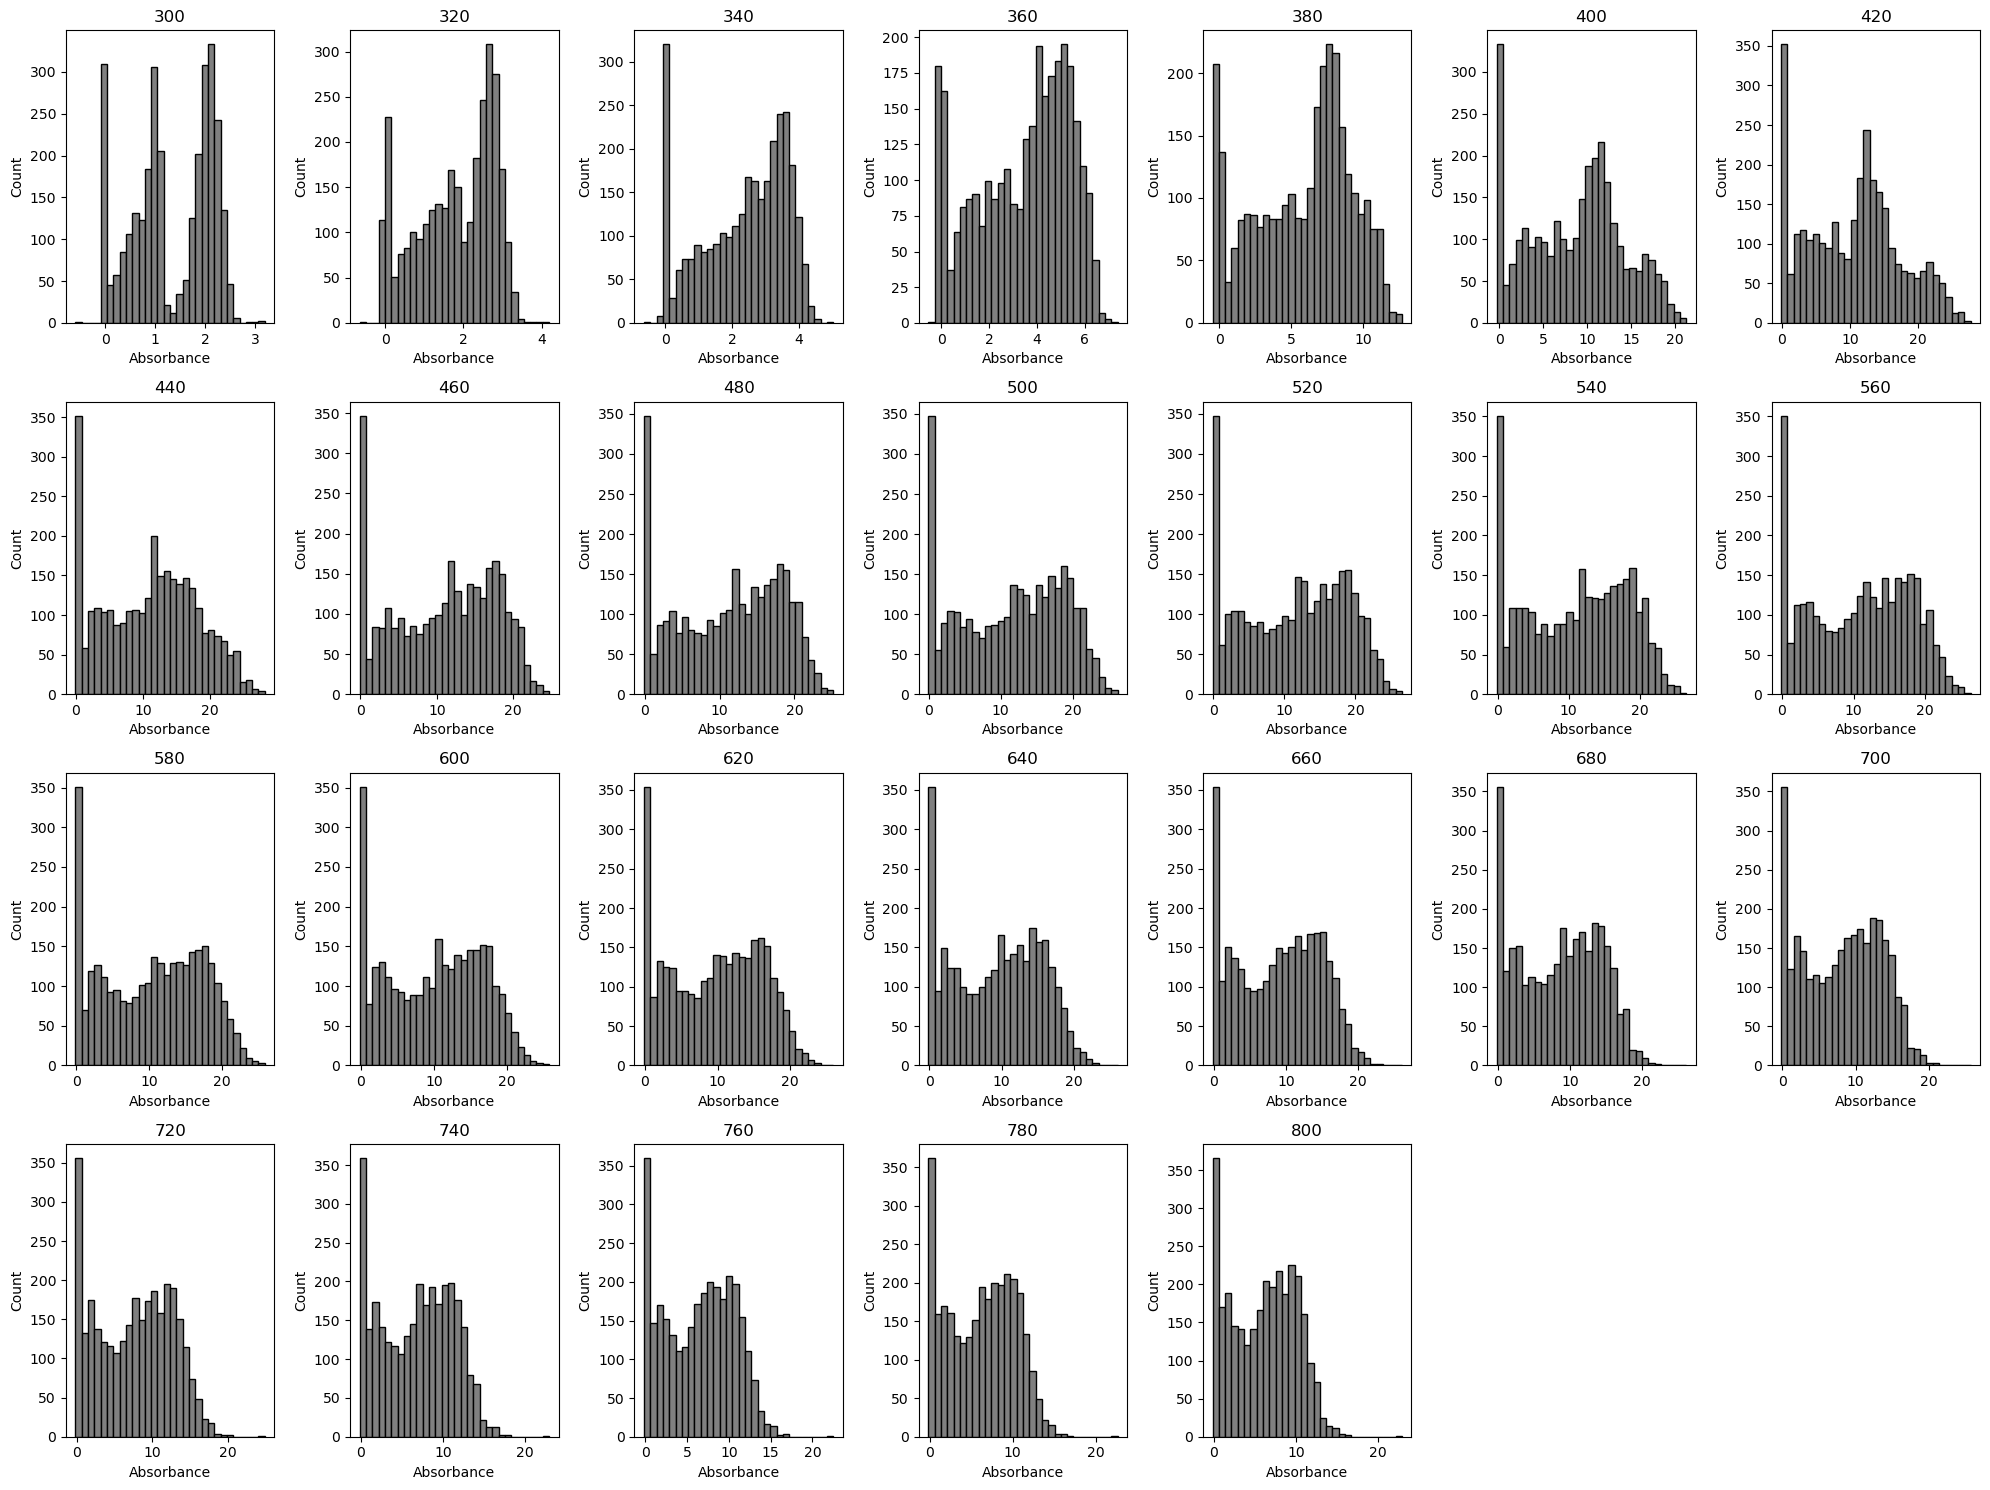

In [5]:
#------ PLOT 2 - Per wavelength
# Select columns
cols = df_clean.loc[:, '300':'800'].columns

# Create one big figure
plt.figure(figsize=(20, 15))

# Loop through each column and plot
for i, col in enumerate(cols):
    plt.subplot(4, 7, i+1)  # Adjust 4x6 grid if you have more/fewer columns
    plt.hist(df[col].dropna(), bins=30, color='gray', edgecolor='black')
    plt.title(col)
    plt.xlabel('Absorbance')
    plt.ylabel('Count')

#plt.title('Distribution per wavelength of normalized Absorbance (bins=30)')
plt.tight_layout()
plt.show()


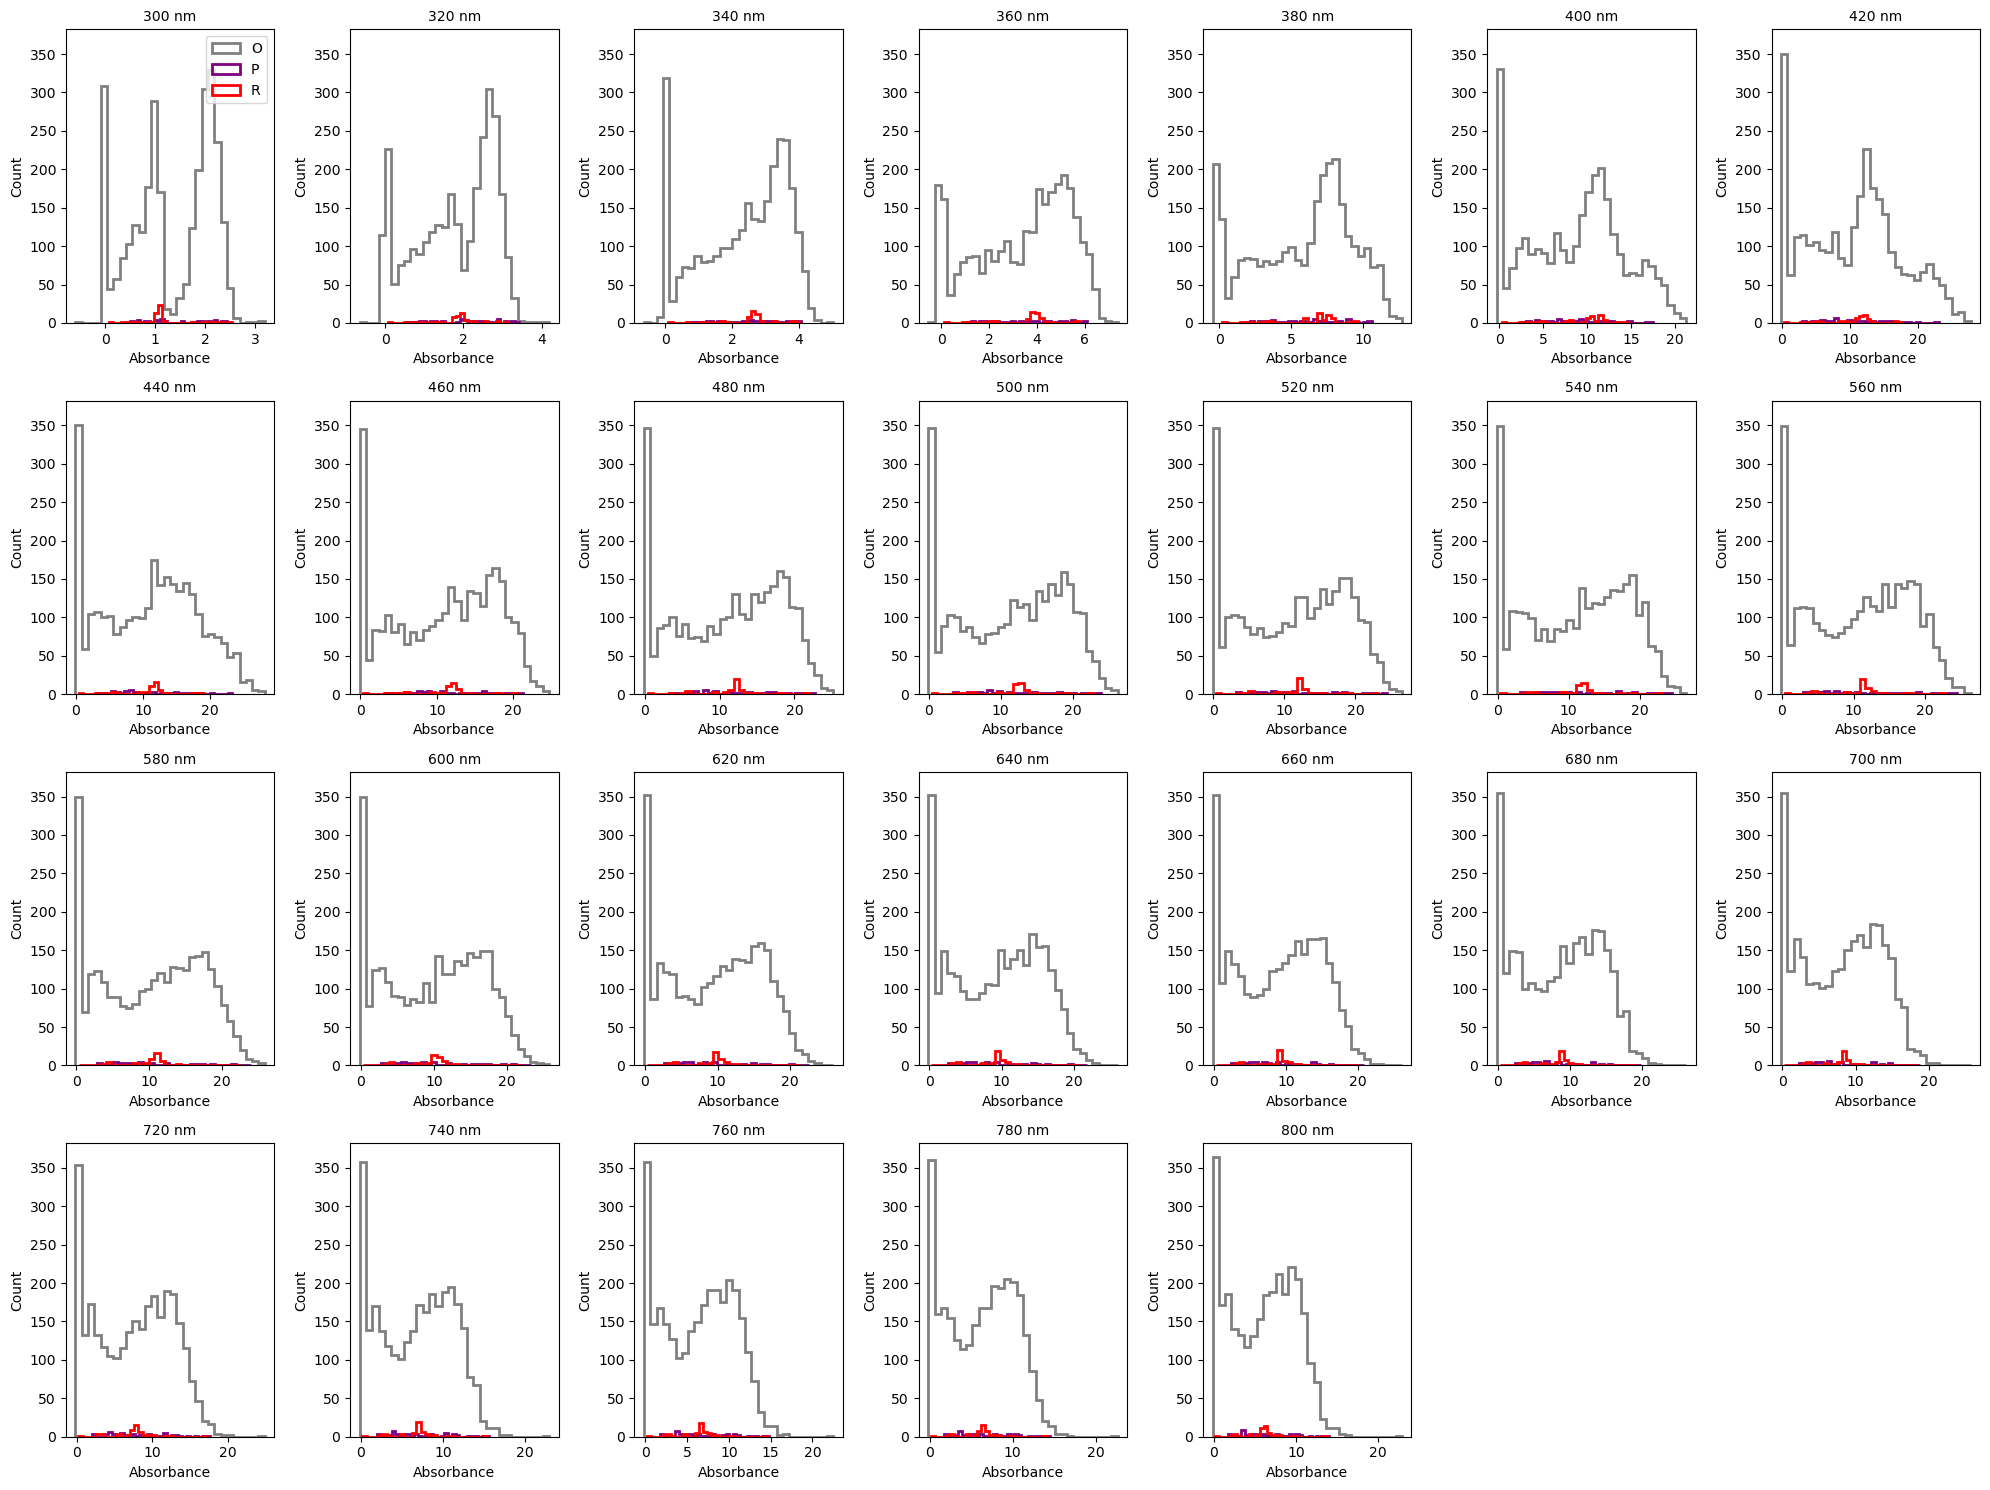

In [6]:
#-----PLOT 3 - Per wavelenth & per tag

# 1. Pre-calculate the global maximum count
# We iterate through all columns and all tags to find the single highest bin count
max_count = 0
cols = df_clean.loc[:, '300':'800'].columns
tags = ['O', 'P', 'R']

for col in cols:
    for tag in tags:
        data = df_clean[df_clean['Color_label'] == tag][col].dropna()
        if len(data) > 0:
            counts, _ = np.histogram(data, bins=30)
            if len(counts) > 0:
                max_count = max(max_count, max(counts))

# Add a small buffer (5%) to the top
y_limit = max_count * 1.05

# 2. Plotting
plt.figure(figsize=(20, 15))

for i, col in enumerate(cols):
    plt.subplot(4, 7, i+1)
    
    # Plot O (Grey) - Curve
    data_o = df_clean[df_clean['Color_label'] == 'O'][col].dropna()
    if len(data_o) > 0:
        plt.hist(data_o, bins=30, histtype='step', linewidth=2, color='gray', label='O')
    
    # Plot P (Purple) - Curve
    data_p = df_clean[df_clean['Color_label'] == 'P'][col].dropna()
    if len(data_p) > 0:
        plt.hist(data_p, bins=30, histtype='step', linewidth=2, color='purple', label='P')
    
    # Plot R (Red) - Curve
    data_r = df_clean[df_clean['Color_label'] == 'R'][col].dropna()
    if len(data_r) > 0:
        plt.hist(data_r, bins=30, histtype='step', linewidth=2, color='red', label='R')
    
    # Apply the fixed Y axis
    plt.ylim(0, y_limit)
    
    plt.title(f"{col} nm", fontsize=10)
    plt.xlabel('Absorbance')
    plt.ylabel('Count')
    
    # Optional: Add legend only to the first plot to avoid clutter
    if i == 0:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 1. PCA on wavelength

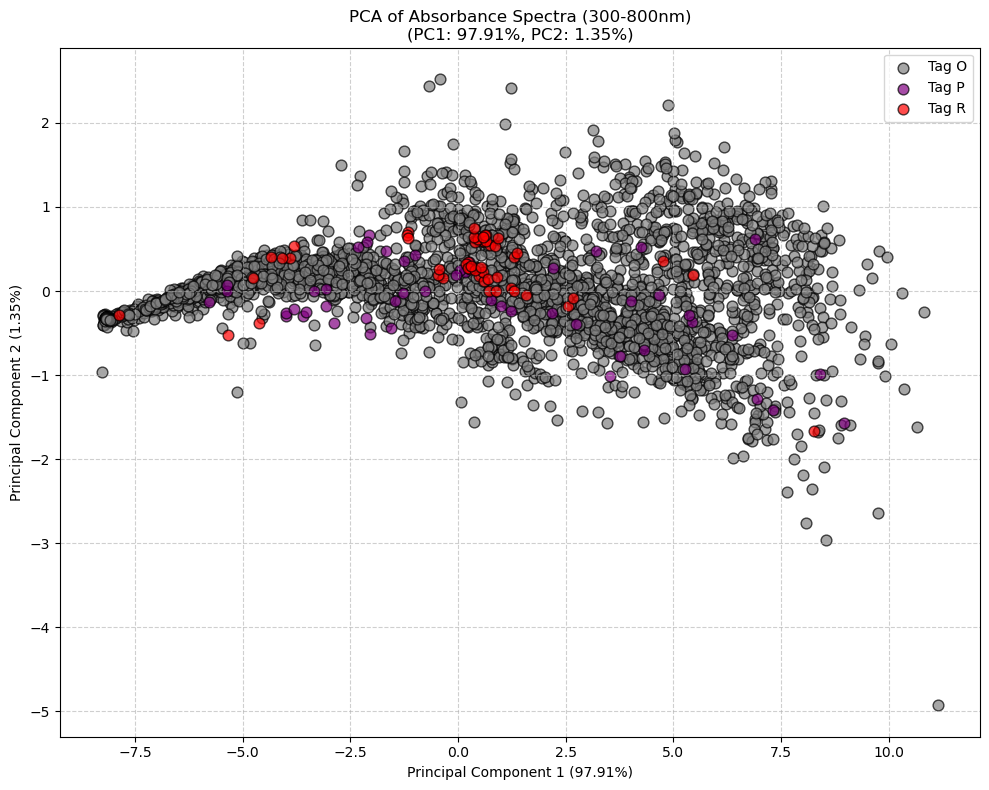

PC1 explains: 97.91% of variance
PC2 explains: 1.35% of variance
Total (PC1+PC2): 99.26%


In [7]:
# 1. Load and Prepare Data
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # Remove "moyenne"

# Select features (Absorbance) and target (Color_label)
X = df_clean.loc[:, '300':'800']
y = df_clean['Color_label'] # Assumes column name is exactly 'Color_label'

# 2. Standardize the Data (Crucial for PCA)
# PCA is sensitive to scale. Since absorbance varies by wavelength, we standardize to mean=0, std=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Color_label'] = y.values

# 4. Plot
plt.figure(figsize=(10, 8))

# Define colors for tags
tags = ['O', 'P', 'R']
colors = {'O': 'gray', 'P': 'purple', 'R': 'red'}

for tag in tags:
    subset = pca_df[pca_df['Color_label'] == tag]
    plt.scatter(subset['PC1'], subset['PC2'], 
                c=colors[tag], label=f'Tag {tag}', 
                alpha=0.7, edgecolors='k', s=60)

plt.title(f'PCA of Absorbance Spectra (300-800nm)\n(PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Print how much variance is explained
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total (PC1+PC2): {sum(pca.explained_variance_ratio_[:2]):.2%}")

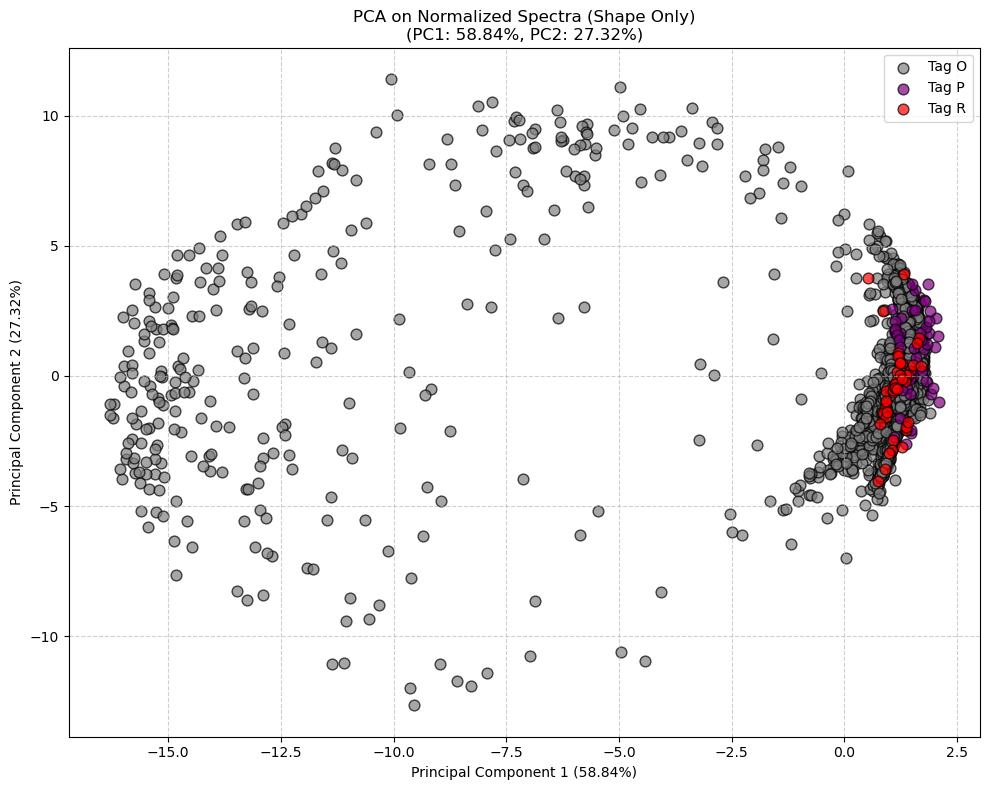

PC1 explains: 58.84%
PC2 explains: 27.32%


In [8]:

# 1. Load and Prepare Data
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True)

X = df_clean.loc[:, '300':'800']
y = df_clean['Color_label']

# 2. Pre-processing: Row-wise Normalization (SNV-like)
# This removes the "concentration" effect so PCA focuses on "shape"
# Step A: Subtract the mean of each row (center the spectrum)
X_centered = X.sub(X.mean(axis=1), axis=0)

# Step B: Divide by the standard deviation of each row (scale the spectrum)
# Add a tiny epsilon to avoid division by zero if a row is perfectly flat
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# 3. Column Standardization (Still needed for PCA to treat all wavelengths equally)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)

# 4. Run PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_final)

# Create DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Color_label'] = y.values

# 5. Plot
plt.figure(figsize=(10, 8))
tags = ['O', 'P', 'R']
colors = {'O': 'gray', 'P': 'purple', 'R': 'red'}

for tag in tags:
    subset = pca_df[pca_df['Color_label'] == tag]
    plt.scatter(subset['PC1'], subset['PC2'], 
                c=colors[tag], label=f'Tag {tag}', 
                alpha=0.7, edgecolors='k', s=60)

plt.title(f'PCA on Normalized Spectra (Shape Only)\n(PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%}")

## Random Forest model

📉 Training set: 2457 samples
🧪 Test set: 615 samples
=== RANDOM FOREST ===
              precision    recall  f1-score   support

           O       0.98      1.00      0.99       595
           P       1.00      0.40      0.57        10
           R       0.83      0.50      0.62        10

    accuracy                           0.98       615
   macro avg       0.94      0.63      0.73       615
weighted avg       0.98      0.98      0.98       615

[[594   0   1]
 [  6   4   0]
 [  5   0   5]]

=== MLP CLASSIFIER ===
              precision    recall  f1-score   support

           O       0.99      0.98      0.99       595
           P       0.45      0.50      0.48        10
           R       0.60      0.60      0.60        10

    accuracy                           0.97       615
   macro avg       0.68      0.69      0.69       615
weighted avg       0.97      0.97      0.97       615

[[586   5   4]
 [  5   5   0]
 [  3   1   6]]


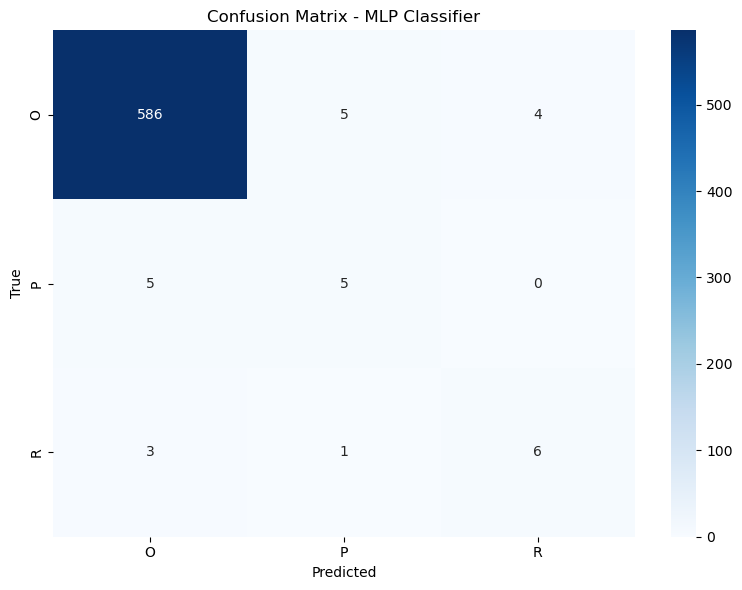

In [9]:
# 1. Load and Prepare Data
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # Remove 'moyenne'
label_col = 'Color_label'
id_col = 'SampleID'


X = df_clean.loc[:, '300':'800']
y = df_clean['Color_label']

# 2. Row-wise Normalization (Focus on Shape)
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# Column Standardization (Required for consistency, though RF is robust)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)


print(f"📉 Training set: {len(X_train)} samples")
print(f"🧪 Test set: {len(X_test)} samples")


# 4. Train Random Forest
# n_estimators=100 is a good default. random_state ensures reproducible results.
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- MODEL 2: MLP Classifier (Balanced) ---
# hidden_layer_sizes: (100,) is a standard default. 
# class_weight='balanced' is crucial for reducing false negatives on rare classes.
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)


# --- RESULTS ---
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf)) 

print("\n=== MLP CLASSIFIER ===")
print(classification_report(y_test, y_pred_mlp))
print(confusion_matrix(y_test, y_pred_mlp))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_mlp, labels=rf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title('Confusion Matrix - MLP Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



This is a promising result ! There are still a lot of false negative. To improve the model, we will try to :
- filter empty wells
- filter Pseudomonas fluorescente wells 
- add color samples from previous experiment
- check false IDs for patterns > mislabeled ?

## Second data cleaning round

### Remove empty wells

Original rows: 3072
Filtered rows: 2501
Removed: 571 samples with Abs(300nm) <= 0.5
Remaining colored samples: 97.0/104


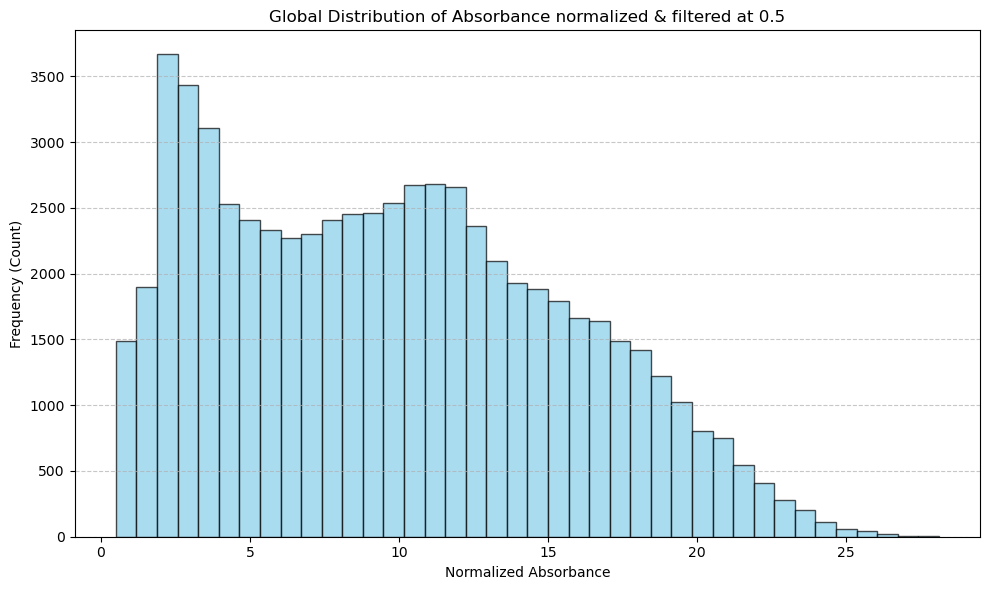

In [10]:
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # remove the "moyenne" row

# --- 2. FILTER DATA ---
# Keep only rows where absorbance at 300nm is strictly greater than 0
# We use > 0 to remove both negatives and exact zeros
filtered_df = df_clean[df_clean['300'] > 0.5].reset_index(drop=True)

# --- 3. VERIFY ---
print(f"Original rows: {len(df_clean)}")
print(f"Filtered rows: {len(filtered_df)}")
print(f"Removed: {len(df_clean) - len(filtered_df)} samples with Abs(300nm) <= 0.5")
print(f"Remaining colored samples: {(filtered_df["Binary"].sum())}/104")

# You can now use 'filtered_df' for your PCA or Model training
ids = filtered_df.iloc[:, 0:1]
abs_columns = filtered_df.loc[:, '300':'800']
tags = filtered_df.iloc[:, 27:29]

all_values = abs_columns.values.flatten()

# --- Plot 1: Global Histogram (All Wavelengths Combined) ---
plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Global Distribution of Absorbance normalized & filtered at 0.5')
plt.xlabel('Normalized Absorbance')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Remove fluorescent wells

Now that we removed empty wells (771), we also want to remove the wells that probably contain fluorescent Pseudomonas that were clustering on the left on the PCA plot.  

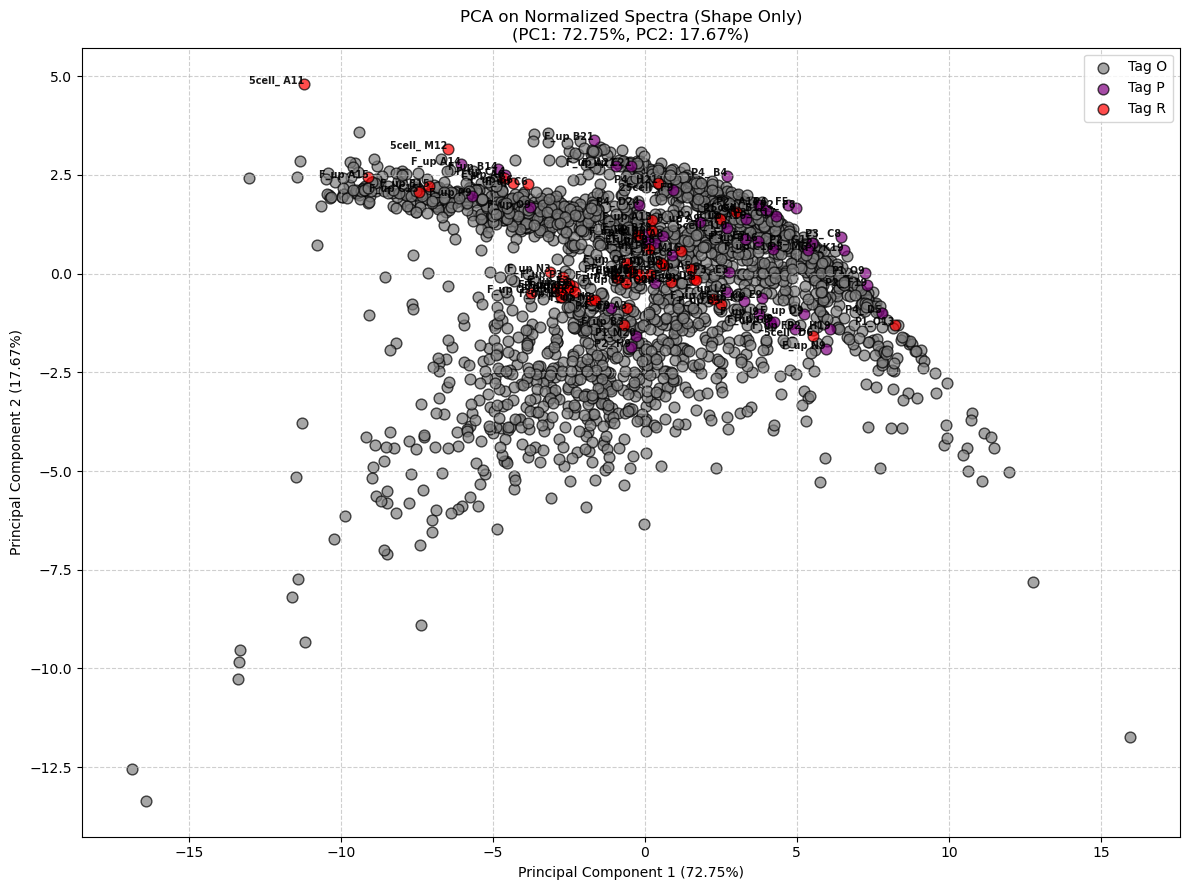

In [11]:


# Extract IDs for labeling
sample_ids = filtered_df.iloc[:, 0] # Assuming first column is SampleID
X = filtered_df.loc[:, '300':'800']
y = filtered_df['Color_label']

# 2. Pre-processing: Row-wise Normalization
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# 3. Column Standardization
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)

# 4. Run PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_final)

# Create DataFrame including IDs
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Color_label'] = y.values
pca_df['SampleID'] = sample_ids.values

# 5. Plot with Labels
plt.figure(figsize=(12, 9)) # Slightly larger figure to accommodate text
tags = ['O', 'P', 'R']
colors = {'O': 'gray', 'P': 'purple', 'R': 'red'}

# Plot all points first
for tag in tags:
    subset = pca_df[pca_df['Color_label'] == tag]
    plt.scatter(subset['PC1'], subset['PC2'], 
                c=colors[tag], label=f'Tag {tag}', 
                alpha=0.7, edgecolors='k', s=60)

# Plot labels ONLY for colored wells (Not 'O')
colored_wells = pca_df[pca_df['Color_label'] != 'O']

for i, row in colored_wells.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['SampleID']), 
             fontsize=7, alpha=0.9, ha='right', fontweight='bold')

plt.title(f'PCA on Normalized Spectra (Shape Only)\n(PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

It looks like samples P3_K23, P3_I14, P2_J24 and F_up_C3 are not really colored, so I changed their label to 0. 
Now, I labelled few strongly fluorescent wells to see were they show up on the PCA. If they are actually the datapoint that have a low PC2, we could filter them !

Original rows: 3072
Filtered rows: 2501
Removed: 571 samples with Abs(300nm) <= 0.5
Remaining colored samples: 97.0/104


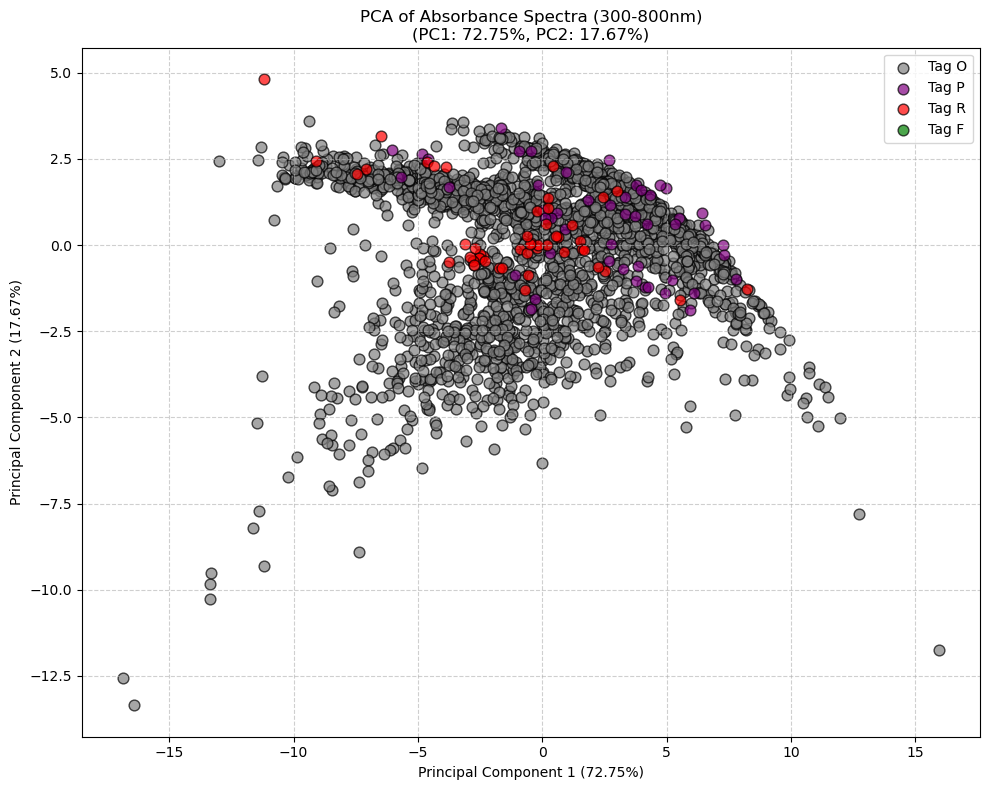

PC1 explains: 72.75% of variance
PC2 explains: 17.67% of variance


In [16]:
# Re-import updated data - keep IDs
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # remove the "moyenne" row

# --- 2. FILTER DATA ---
# Keep only rows where absorbance at 300nm is strictly greater than 0
# We use > 0 to remove both negatives and exact zeros
filtered_df = df_clean[df_clean['300'] > 0.5].reset_index(drop=True)

# --- 3. VERIFY ---
print(f"Original rows: {len(df_clean)}")
print(f"Filtered rows: {len(filtered_df)}")
print(f"Removed: {len(df_clean) - len(filtered_df)} samples with Abs(300nm) <= 0.5")
print(f"Remaining colored samples: {(filtered_df["Binary"].sum())}/104")

# You can now use 'filtered_df' for your PCA or Model training
ids = filtered_df.iloc[:, 0:1]
abs_columns = filtered_df.loc[:, '300':'800']
tags = filtered_df.iloc[:, 27:29]

# Normalize - loi centrée réduite
X = filtered_df.loc[:, '300':'800']
y = filtered_df['Color_label']

# 2. Row-wise Normalization (Focus on Shape)
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# Column Standardization (Required for consistency, though RF is robust)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)

# PCA again

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_final)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Color_label'] = y.values

# 4. Plot
plt.figure(figsize=(10, 8))

# Define colors for tags
tags = ['O', 'P', 'R', 'F']
colors = {'O': 'gray', 'P': 'purple', 'R': 'red', 'F':'green'}

for tag in tags:
    subset = pca_df[pca_df['Color_label'] == tag]
    plt.scatter(subset['PC1'], subset['PC2'], 
                c=colors[tag], label=f'Tag {tag}', 
                alpha=0.7, edgecolors='k', s=60)

plt.title(f'PCA of Absorbance Spectra (300-800nm)\n(PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Print how much variance is explained
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%} of variance")


Fluorescent wells actually don't really cluster together, so no point removing them. We can try to run the ML models again !

### Train models round 2

We keep the IDs to track the samples that are misclassified.

Original rows: 3072
Filtered rows: 2501
Removed: 571 samples with Abs(300nm) <= 0.5
Remaining colored samples: 97.0/104
📉 Training set: 2000 samples
🧪 Test set: 501 samples
Total MLP Errors: 8

--- List of Misclassified Sample IDs (RF) ---
SampleID True_Label Predicted_MLP
F_up A13          R             O
  P3_ M6          P             O
 F_up P9          P             O
 F_up N3          R             O
 F_up C9          P             O
 F_up B6          R             O
 F_up N9          P             O
 F_up C6          R             O
Total MLP Errors: 7

--- List of Misclassified Sample IDs (MLP) ---
SampleID True_Label Predicted_MLP
 P4_ A17          O             P
  P3_ M6          P             O
 F_up P9          P             O
 F_up C9          P             O
F_up A23          O             P
 F_up N9          P             O
 F_up C6          R             O
=== RANDOM FOREST ===
              precision    recall  f1-score   support

           O       0.98      1.00    

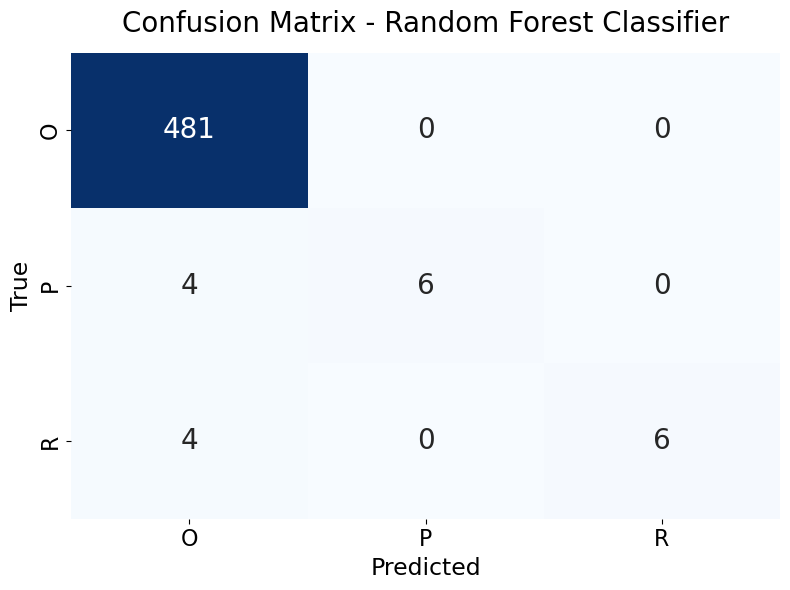


=== MLP CLASSIFIER ===
              precision    recall  f1-score   support

           O       0.99      1.00      0.99       481
           P       0.75      0.60      0.67        10
           R       1.00      0.90      0.95        10

    accuracy                           0.99       501
   macro avg       0.91      0.83      0.87       501
weighted avg       0.99      0.99      0.99       501

[[479   2   0]
 [  4   6   0]
 [  1   0   9]]


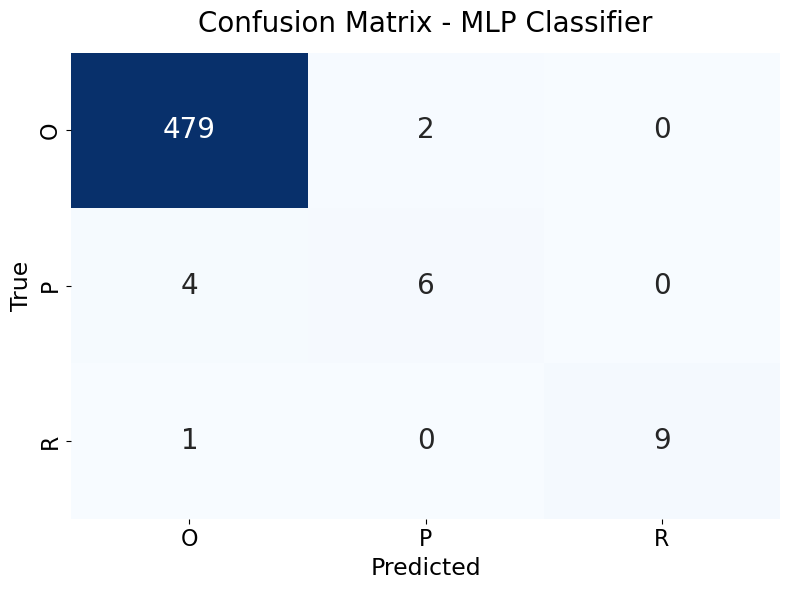

In [6]:
# Re-import updated data - keep IDs
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True) # remove the "moyenne" row

# --- 2. FILTER DATA ---
# Keep only rows where absorbance at 300nm is strictly greater than 0
# We use > 0 to remove both negatives and exact zeros
filtered_df = df_clean[df_clean['300'] > 0.5].reset_index(drop=True)

# --- 3. VERIFY ---
print(f"Original rows: {len(df_clean)}")
print(f"Filtered rows: {len(filtered_df)}")
print(f"Removed: {len(df_clean) - len(filtered_df)} samples with Abs(300nm) <= 0.5")
print(f"Remaining colored samples: {(filtered_df["Binary"].sum())}/104")

# You can now use 'filtered_df' for your PCA or Model training
ids = filtered_df.iloc[:, 0:1]
abs_columns = filtered_df.loc[:, '300':'800']
tags = filtered_df.iloc[:, 27:29]

# Normalize - loi centrée réduite
X = filtered_df.loc[:, '300':'800']
y = filtered_df['Color_label']
wavelengths = X.columns.astype(int)
wavelengths_str = X.columns.tolist()

# 2. Row-wise Normalization (Focus on Shape)
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# Column Standardization (Required for consistency, though RF is robust)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)



# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# recover IDs 
test_indices = y_test.index

# 2. Retrieve the Sample IDs from your original filtered_df using those indices
# Assumes the Sample ID is in the very first column (index 0)
misclassified_ids = filtered_df.iloc[test_indices, 0]

print(f"📉 Training set: {len(X_train)} samples")
print(f"🧪 Test set: {len(X_test)} samples")


# 4. Train Random Forest
# n_estimators=100 is a good default. random_state ensures reproducible results.
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. Create a DataFrame to compare True vs Predicted
results_rf = pd.DataFrame({
    'SampleID': misclassified_ids,
    'True_Label': y_test.values,
    'Predicted_MLP': y_pred_rf
})

# 4. Filter to keep ONLY the errors (where True != Predicted)
errors_rf = results_rf[results_rf['True_Label'] != results_rf['Predicted_MLP']]

# 5. Print the result
print(f"Total MLP Errors: {len(errors_rf)}")
if len(errors_rf) > 0:
    print("\n--- List of Misclassified Sample IDs (RF) ---")
    print(errors_rf.to_string(index=False))

else:
    print("No errors found.")

# --- MODEL 2: MLP Classifier ---
# hidden_layer_sizes: (100,) is a standard default. 
# class_weight='balanced' is crucial for reducing false negatives on rare classes.
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# 3. Create a DataFrame to compare True vs Predicted
results_mlp = pd.DataFrame({
    'SampleID': misclassified_ids,
    'True_Label': y_test.values,
    'Predicted_MLP': y_pred_mlp
})

# 4. Filter to keep ONLY the errors (where True != Predicted)
errors_mlp = results_mlp[results_mlp['True_Label'] != results_mlp['Predicted_MLP']]

# 5. Print the result
print(f"Total MLP Errors: {len(errors_mlp)}")
if len(errors_mlp) > 0:
    print("\n--- List of Misclassified Sample IDs (MLP) ---")
    print(errors_mlp.to_string(index=False))

else:
    print("No errors found.")

# --- RESULTS ---
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf)) 

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 20},
            xticklabels=rf.classes_, yticklabels=rf.classes_, cbar=False)
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=20, pad=15)
plt.xlabel('Predicted', fontsize=17)
plt.ylabel('True', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


print("\n=== MLP CLASSIFIER ===")
print(classification_report(y_test, y_pred_mlp))
print(confusion_matrix(y_test, y_pred_mlp))

plt.figure(figsize=(8, 6))
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=rf.classes_)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 20},
            xticklabels=rf.classes_, yticklabels=rf.classes_, cbar=False)
plt.title('Confusion Matrix - MLP Classifier', fontsize=20, pad=15)
plt.xlabel('Predicted', fontsize=17)
plt.ylabel('True', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


In [28]:
#----- SAVE MLP Classifier

# Define filenames
model_filename = "mlp_pigment_classifier_v1.pkl"
scaler_filename = "standard_scaler_v1.pkl"

# Save the trained MLP model
joblib.dump(mlp, model_filename)
print(f"✅ Model saved as '{model_filename}'")

# Save the fitted StandardScaler (Column scaling)
# Note: The Row-wise normalization is code-based, not a fitted object, so it doesn't need saving.
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved as '{scaler_filename}'")

# Optional: Save the list of expected columns to ensure future data matches
columns_filename = "expected_columns.pkl"
joblib.dump(list(X.columns), columns_filename)
print(f"✅ Column order saved as '{columns_filename}'")

✅ Model saved as 'mlp_pigment_classifier_v1.pkl'
✅ Scaler saved as 'standard_scaler_v1.pkl'
✅ Column order saved as 'expected_columns.pkl'


The result is pretty good compared to the first dataset, and slightly better than the first dataset. 

## Model simplification for red screen




Full Model Accuracy: 0.9860

=== TOP 10 MOST IMPORTANT WAVELENGTHS (MLP Weight Analysis) ===
    Wavelength Wavelength_Str  Importance
7          440            440   25.182317
11         520            520   25.134870
10         500            500   22.244282
0          300            300   21.913448
4          380            380   21.616533
9          480            480   21.246850
8          460            460   20.852220
12         540            540   20.842696
5          400            400   20.281721
2          340            340   19.365239


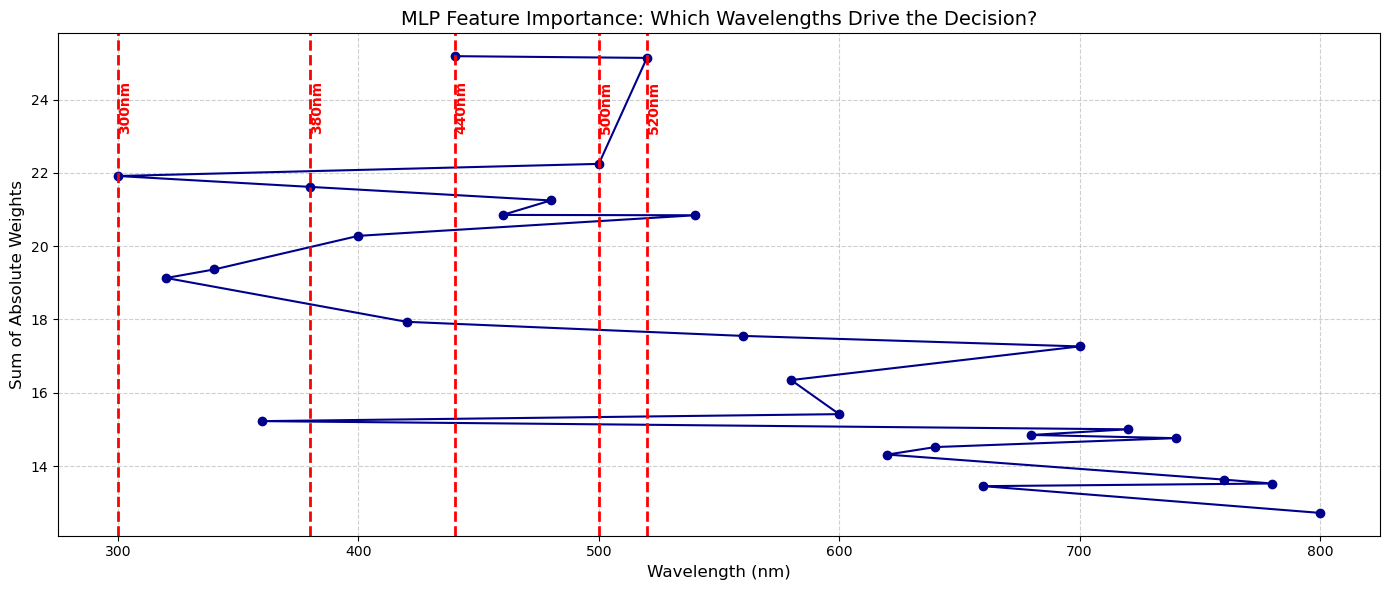


--- Testing Simplified MLP with Top 12 Wavelengths: ['440', '520', '500', '300', '380', '480', '460', '540', '400', '340', '320', '420'] ---

=== COMPARISON ===
Full Model (26 wavelengths) Accuracy:  0.9860
Simplified Model (12 wavelengths) Accuracy: 0.9840

Classification Report (Simplified Model):
              precision    recall  f1-score   support

           O       0.99      0.99      0.99       481
           P       0.86      0.60      0.71        10
           R       0.82      0.90      0.86        10

    accuracy                           0.98       501
   macro avg       0.89      0.83      0.85       501
weighted avg       0.98      0.98      0.98       501

[[478   1   2]
 [  4   6   0]
 [  1   0   9]]


In [15]:
print(f"Full Model Accuracy: {mlp.score(X_test, y_test):.4f}")

# 3. Extract Feature Importance from MLP Weights
# The weights connecting Input -> Hidden Layer 0 are stored in mlp_full.coefs_[0]
# Shape: (n_features, n_hidden_neurons)
input_weights = mlp.coefs_[0]

# Calculate Importance: Sum of absolute weights for each input feature
# This tells us how much each wavelength influences the hidden neurons
importance_scores = np.sum(np.abs(input_weights), axis=1)

# Create a DataFrame to sort wavelengths by importance
importance_df = pd.DataFrame({
    'Wavelength': wavelengths,
    'Wavelength_Str': wavelengths_str,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

print("\n=== TOP 10 MOST IMPORTANT WAVELENGTHS (MLP Weight Analysis) ===")
print(importance_df.head(10))

# 4. Plot Importance Spectrum
plt.figure(figsize=(14, 6))
plt.plot(importance_df['Wavelength'], importance_df['Importance'], marker='o', linestyle='-', color='darkblue')
plt.title('MLP Feature Importance: Which Wavelengths Drive the Decision?', fontsize=14)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Sum of Absolute Weights', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight Top 5
top_5_wls = importance_df.head(5)['Wavelength'].values
for wl in top_5_wls:
    plt.axvline(wl, color='red', linestyle='--', linewidth=2)
    plt.text(wl, plt.ylim()[1]*0.95, f'{wl}nm', rotation=90, va='top', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Build and Test a SIMPLIFIED MLP (The "Student" Model)
# Select only the Top N wavelengths
N = 12  # Try 5, then try 3
top_n_cols = importance_df.head(N)['Wavelength_Str'].tolist()
print(f"\n--- Testing Simplified MLP with Top {N} Wavelengths: {top_n_cols} ---")

# Slice the original normalized data to keep ONLY these columns
# Note: We must re-run the normalization pipeline on this subset to be rigorous
X_subset = filtered_df.loc[:, top_n_cols]

# Row-wise Normalization on subset
X_sub_centered = X_subset.sub(X_subset.mean(axis=1), axis=0)
X_sub_normalized = X_sub_centered.div(X_sub_centered.std(axis=1) + 1e-9, axis=0)

# Column Standardization on subset
scaler_sub = StandardScaler()
X_sub_final = scaler_sub.fit_transform(X_sub_normalized)

# Split
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_sub_final, y, test_size=0.2, random_state=42, stratify=y)

# Train a tiny MLP (fewer neurons needed for fewer inputs)
mlp_simple = MLPClassifier(hidden_layer_sizes=(20,), max_iter=1000, random_state=42, alpha=0.001)
mlp_simple.fit(Xs_train, ys_train)

# Compare Performance
print("\n=== COMPARISON ===")
print(f"Full Model (26 wavelengths) Accuracy:  {mlp.score(X_test, y_test):.4f}")
print(f"Simplified Model ({N} wavelengths) Accuracy: {mlp_simple.score(Xs_test, ys_test):.4f}")

print("\nClassification Report (Simplified Model):")
print(classification_report(ys_test, mlp_simple.predict(Xs_test)))
print(confusion_matrix(ys_test, mlp_simple.predict(Xs_test)))



Simplificatio of a mlp model is tricky ! First, it works better with red and purple tags (compared to only O and red). 
The model in kind of working with half of the wavelength : it spots 7 wells out of 10 with the wavelengths ['440', '520', '500', '300', '380', '480', '460', '540', '400', '340']

With 11 : 8/10, R precision = 0.89, 1 false positive
With 12 : 9/10 or as well as with the 20 wavelengths, R precision = 0.82, plus 2 false positive,  ['440', '520', '500', '300', '380', '480', '460', '540', '400', '340', '320', '420']


### Troubleshooting purple

Let's check if removing the Red class helps it to classify better the purple > replace Color_label_OPR by OP in the excel datasheet and rerun. 
The output is equal for RF, worse for MLP.

Now, it would be interesting to explore the samples classified wrong :

--- List of Misclassified Sample IDs (RF) ---
SampleID True_Label Predicted_MLP
 F_up F5          R             O
 F_up D9          P             O
 P4_ D24          P             O
 F_up L5          R             O
  P4_ D5          P             O
 F_up M3          R             O
 F_up E9          P             O
 F_up I5          R             O

--- List of Misclassified Sample IDs (MLP) ---
SampleID True_Label Predicted_MLP
 F_up P4          O             P
 **F_up D9          P             O**
 **P4_ D24          P             O**
 **P4_ D5          P             O**
 P2_ F23          O             P
 **F_up E9          P             O**
 F_up I5          R             O


So we can check the absorbance spectra of these misclassified sample by plotting.

Green samples (Correct P): 45
Purple samples (Errors): 4
✅ Green plotted.
Plotting 4 misclassified samples...
✅ Purple plotted.


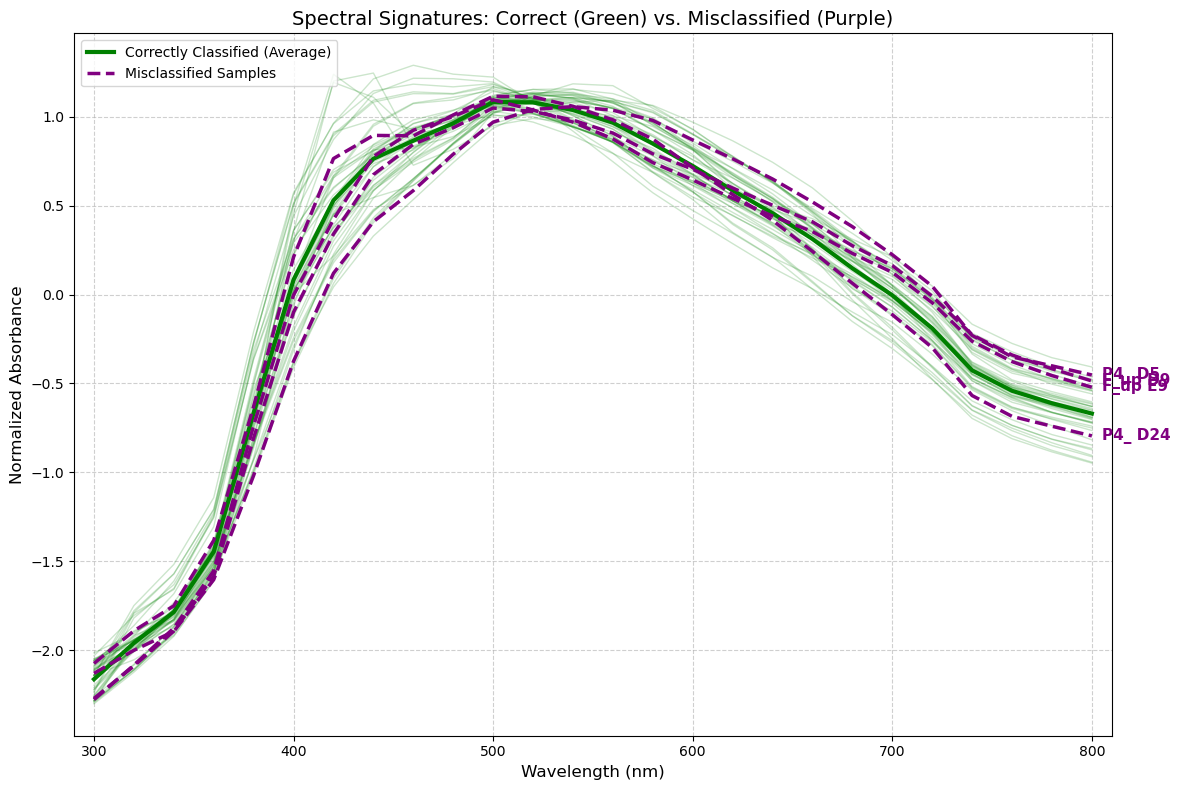

In [ ]:
# 1. Load and Prepare Data
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True)

# Filter
filtered_df = df_clean[df_clean['300'] > 0.5].reset_index(drop=True)

# Clean IDs and Labels
ids_clean = filtered_df.iloc[:, 0].astype(str).str.strip()
labels_clean = filtered_df['Color_label'].astype(str).str.strip()

X = filtered_df.loc[:, '300':'800']
wavelengths = X.columns.astype(int)

# 2. Row-wise Normalization
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)

# 3. Define Misclassified IDs
error_id_list = ['P4_ D24', 'P4_ D5', 'F_up D9', 'F_up E9']
error_id_list_clean = [str(x).strip() for x in error_id_list]

# Create Masks
mask_misclassified = ids_clean.isin(error_id_list_clean)
mask_correct = (labels_clean == 'P') & (~mask_misclassified)

print(f"Green samples (Correct P): {mask_correct.sum()}")
print(f"Purple samples (Errors): {mask_misclassified.sum()}")

# 4. Plotting
# Increased height to accommodate text labels on the right
plt.figure(figsize=(14, 8)) 

# --- PLOT GREEN (Correct) ---
correct_data = X_normalized[mask_correct]
if len(correct_data) > 0:
    # Plot individual lines WITHOUT label (prevents legend explosion)
    for idx, row in correct_data.iterrows():
        plt.plot(wavelengths, row.values, color='green', alpha=0.2, linewidth=1)
    
    # Plot Average WITH label
    plt.plot(wavelengths, correct_data.mean(axis=0), color='green', linewidth=3, label='Correctly Classified (Average)')
    print("✅ Green plotted.")

# --- PLOT PURPLE (Misclassified) ---
misclassified_data = X_normalized[mask_misclassified]

if len(misclassified_data) > 0:
    print(f"Plotting {len(misclassified_data)} misclassified samples...")
    
    first_error = True
    for idx, row in misclassified_data.iterrows():
        sample_id = ids_clean.iloc[idx]
        
        # ONLY add label to the first error line to keep legend clean
        if first_error:
            plt.plot(wavelengths, row.values, color='purple', linewidth=2.5, linestyle='--', 
                     label=f'Misclassified Samples')
            first_error = False
        else:
            # No label for subsequent lines
            plt.plot(wavelengths, row.values, color='purple', linewidth=2.5, linestyle='--')
        
        # Add text label at the end (800nm)
        # We add a little padding to x (810) so text doesn't overlap the line end
        plt.text(805, row.iloc[-1], f"{sample_id}", color='purple', fontsize=11, fontweight='bold', va='center')
    
    print("✅ Purple plotted.")
else:
    print("⚠️ No purple samples found.")
    # Debug: Show available IDs similar to what we look for
    print(f"Available IDs containing 'P4': {ids_clean[ids_clean.str.contains('P4', na=False)].tolist()}")

# Final Formatting
plt.title('Spectral Signatures: Correct (Green) vs. Misclassified (Purple)', fontsize=14)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Normalized Absorbance', fontsize=12)
plt.legend(loc='upper left') # Move legend to top-left to avoid right-side text
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(290, 810) # Extend x-axis slightly to ensure text labels at 800nm are visible
plt.ylim(bottom=None) # Let matplotlib auto-scale Y

# Tight layout with extra space on the right for the text labels
plt.tight_layout(rect=[0, 0, 0.85, 1]) 

plt.show()

Total Test Samples: 501

--- TEST SET ANALYSIS (Purple Samples) ---
Misclassified P IDs: ['P4_ O24', 'F_up C9', 'F_up E9', 'F_up B14', 'F_up O9']
Well-classified P IDs: ['P4_ D24', '5cell_ I10', 'P2_ F8', 'F_up A8', 'F_up K9']


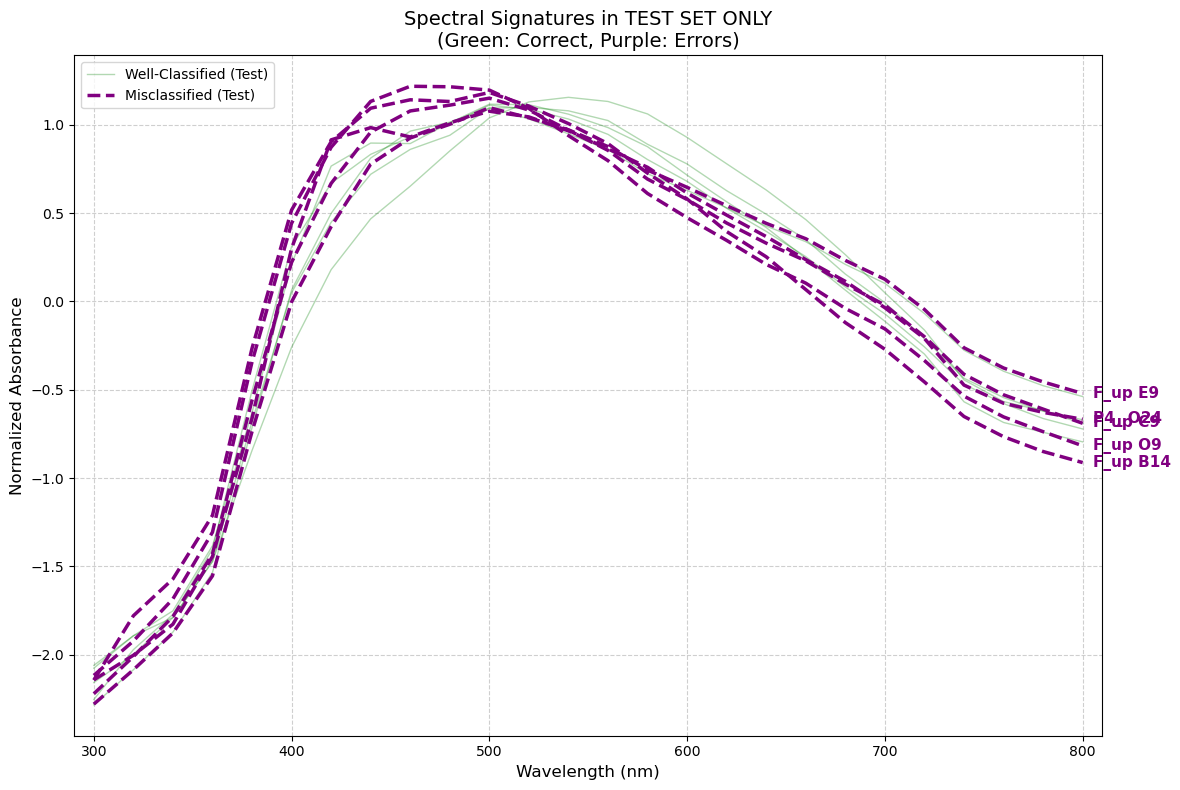


=== MLP TEST PERFORMANCE ===
              precision    recall  f1-score   support

           O       0.99      1.00      0.99       491
           P       0.71      0.50      0.59        10

    accuracy                           0.99       501
   macro avg       0.85      0.75      0.79       501
weighted avg       0.98      0.99      0.98       501



In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. LOAD & PREPARE DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier384/Data_classifier384_20nm_mblank.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
df_clean = df.iloc[1:].reset_index(drop=True)

# Filter
filtered_df = df_clean[df_clean['300'] > 0.5].reset_index(drop=True)

# Extract Features and Labels
ids_all = filtered_df.iloc[:, 0].astype(str).str.strip() # Clean IDs
X = filtered_df.loc[:, '300':'800']
y = filtered_df['Color_label'].astype(str).str.strip()

# Preprocessing (Row-wise + Column-wise)
X_centered = X.sub(X.mean(axis=1), axis=0)
X_normalized = X_centered.div(X_centered.std(axis=1) + 1e-9, axis=0)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_normalized)

wavelengths = X.columns.astype(int)

# --- 2. SPLIT DATA (MUST HAPPEN BEFORE GETTING INDICES) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# Get the original indices of the TEST set only
test_indices = y_test.index 

# Retrieve Sample IDs for the TEST set only
test_ids = ids_all.iloc[test_indices]
test_labels_true = y_test.values

print(f"Total Test Samples: {len(test_ids)}")

# --- 3. TRAIN MODEL & PREDICT ---
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# --- 4. IDENTIFY WELL vs MISCLASSIFIED IDs ---
# Create a DataFrame for the Test Set only
test_results = pd.DataFrame({
    'SampleID': test_ids,
    'True_Label': test_labels_true,
    'Predicted': y_pred_mlp
})

# Mask for Errors (True != Predicted) AND Label is 'P' (Purple)
# We focus on 'P' because your previous plot was about Purple samples
mask_errors_P = (test_results['True_Label'] != test_results['Predicted']) & (test_results['True_Label'] == 'P')
mask_correct_P = (test_results['True_Label'] == test_results['Predicted']) & (test_results['True_Label'] == 'P')

error_ids_P = test_results.loc[mask_errors_P, 'SampleID'].tolist()
correct_ids_P = test_results.loc[mask_correct_P, 'SampleID'].tolist()

print(f"\n--- TEST SET ANALYSIS (Purple Samples) ---")
print(f"Misclassified P IDs: {error_ids_P}")
print(f"Well-classified P IDs: {correct_ids_P}")

# If lists are empty, fallback to manual list for demonstration (remove this in production)
if not error_ids_P:
    print("⚠️ No Purple errors found in this specific random test split.")
    print("   Using manual list for plotting demonstration purposes.")
    # Replace with your known errors if the random split didn't catch them this time
    error_ids_P = ['P2_ P4', 'P3_ P4', 'F_up D9', 'F_up E9'] 
    # Note: We will filter these to ensure they are actually in the test set before plotting

# --- 5. PLOT ONLY TEST SAMPLES ---
plt.figure(figsize=(14, 8))

# Helper function to plot specific IDs
def plot_specific_ids(id_list, color, style, label_prefix, alpha=0.2):
    count = 0
    for sample_id in id_list:
        # Find the row index in filtered_df for this ID
        # We must ensure we only pick rows that are ALSO in the test set
        match_mask = (ids_all == sample_id) & (ids_all.index.isin(test_indices))
        
        if match_mask.any():
            idx = match_mask[match_mask].index[0]
            row_data = X_normalized.iloc[idx]
            
            # Plot line
            plt.plot(wavelengths, row_data.values, color=color, linestyle=style, 
                     linewidth=2.5 if style=='--' else 1, alpha=alpha, 
                     label=label_prefix if count==0 else "")
            
            # Add text label if it's an error (dashed line)
            if style == '--':
                plt.text(805, row_data.iloc[-1], f"{sample_id}", color=color, 
                         fontsize=11, fontweight='bold', va='center')
            count += 1
        else:
            # ID not in test set (might happen if using manual fallback list)
            print(f"Skipping {sample_id}: Not in current Test Set.")
    return count

# Plot Well-Classified (Green, Solid, Low Alpha)
n_correct = plot_specific_ids(correct_ids_P, 'green', '-', 'Well-Classified (Test)', alpha=0.3)

# Plot Misclassified (Purple, Dashed, High Alpha)
n_errors = plot_specific_ids(error_ids_P, 'purple', '--', 'Misclassified (Test)', alpha=1.0)

if n_correct == 0 and n_errors == 0:
    print("❌ No samples plotted. The IDs provided are not in the current Test Set.")
    print("   Try changing random_state=42 in train_test_split to get a different split.")
else:
    plt.title(f'Spectral Signatures in TEST SET ONLY\n(Green: Correct, Purple: Errors)', fontsize=14)
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Normalized Absorbance', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(290, 810)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# --- 6. CONFUSION MATRIX (Optional Verification) ---
print("\n=== MLP TEST PERFORMANCE ===")
print(classification_report(y_test, y_pred_mlp))